<img src="logo_UNSAM.jpg" width="180" align="right">

# Trabajo Práctico 3 / TS3 | Romero Marchione, Luz | 12/9/26

<br clear="right">

En esta tarea se analizará el **desparramo espectral** que aparece al calcular la DFT de una señal senoidal cuya frecuencia no coincide exactamente con uno de los bins de la transformada.

Se generará una senoidal de potencia unitaria cuya frecuencia está dada por $f_0=k_0\Delta f$, utilizando tres valores de $k_0$: $N/4$, $N/4+0.25$ y $N/4+0.5$. El primer caso se encuentra exactamente sintonizado con un bin de la DFT, mientras que los otros dos introducen una pequeña desintonía.

Para cada caso se calculará y graficará su espectro de potencia, observando cómo cambia la distribución de potencia entre los distintos bins. Luego se verificará mediante la **identidad de Parseval** que, aunque la potencia se distribuya de manera diferente en frecuencia, la potencia total de la señal se mantiene aproximadamente unitaria.

Finalmente, se repetirá el experimento aplicando **zero padding**, agregando $9N$ ceros al final de las $N$ muestras originales. De esta manera la FFT se calculará con $10N$ puntos, obteniendo una grilla frecuencial más densa que permitirá observar con mayor detalle la forma del espectro y sus lóbulos.

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Fundamentos teóricos</h2>
</div>


### DTFT, DFT y resolución espectral

Como se estudió anteriormente, la **DTFT** permite representar una señal discreta en el dominio de la frecuencia, siendo esta representación continua y periódica cada $2\pi$. La **DFT**, en cambio, toma $N$ muestras de ese espectro en frecuencias discretas:

$$
X[k]=\sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}
$$

Cada coeficiente $X[k]$ corresponde a un *bin* de frecuencia. La separación entre bins se denomina **resolución espectral** y viene dada por $\Delta f=f_s/N$, de modo que la frecuencia correspondiente al bin $k$ es $f_k=k\Delta f$.

Una senoidal se encuentra **sintonizada con la DFT** cuando su frecuencia coincide exactamente con uno de estos bins, es decir, cuando $f_0=k_0\Delta f$ con $k_0$ entero.

### Energía y potencia

Para una secuencia finita de $N$ muestras, su energía se define como $E=\sum |x[n]|^2$, mientras que la potencia media se obtiene dividiendo dicha energía por la cantidad de muestras:

$$
P_x=\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2
$$

Para una senoidal de media nula y amplitud $A$, la potencia media es $P_x=A^2/2$. Por este motivo, en este trabajo se utiliza $A=\sqrt{2}$ para obtener una potencia unitaria. Además, al tratarse de una señal de media aproximadamente nula, su potencia coincide con su varianza.

### Identidad de Parseval

La **identidad de Parseval** establece que la energía de una señal puede calcularse tanto en el dominio temporal como en el frecuencial:

$$
\sum_{n=0}^{N-1}|x[n]|^2=
\frac{1}{N}\sum_{k=0}^{N-1}|X[k]|^2
$$

Dividiendo ambos miembros por $N$, puede expresarse también en términos de potencia media:

$$
P_x=
\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2=
\frac{1}{N^2}\sum_{k=0}^{N-1}|X[k]|^2
$$

### Ventana rectangular y desparramo espectral

Al trabajar con solamente $N$ muestras de una señal, se está aplicando implícitamente una **ventana rectangular**: se conserva la señal dentro del intervalo observado y se considera nula fuera de él.

La transformada de una ventana rectangular presenta un **lóbulo principal y lóbulos laterales**, con una forma similar a una sinc; en tiempo discreto esta respuesta corresponde más precisamente al **kernel de Dirichlet**.

Cuando una senoidal está sintonizada con un bin de la DFT, uno de los bins coincide con el máximo del lóbulo principal y los restantes coinciden con cruces por cero de esta respuesta. Por ello, idealmente toda la potencia aparece concentrada en un único bin.

Si la frecuencia se encuentra entre dos bins, estos ya no coinciden con los cruces por cero y la potencia aparece distribuida entre varios de ellos. Este fenómeno se denomina **desparramo o fuga espectral** (*spectral leakage*).

### Zero padding

El **zero padding** consiste en agregar ceros al final de las muestras originales antes de calcular la DFT. En este trabajo se agregarán $9N$ ceros, por lo que la FFT tendrá una longitud total de $10N$ puntos.

La separación entre los nuevos bins será:

$$
\Delta f_{zp}=\frac{f_s}{10N}=\frac{\Delta f}{10}
$$

Por lo tanto, el zero padding genera una grilla frecuencial más densa y permite observar con mayor detalle la forma de los lóbulos y estimar mejor la posición de sus máximos.

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Desarrollo</h2>
</div>


Para estudiar el efecto del desparramo espectral se generarán tres señales senoidales de potencia unitaria, modificando únicamente su frecuencia respecto de la grilla de la DFT.
A partir de las señales obtenidas se calcularán sus transformadas, se comparará la distribución de potencia en frecuencia y se verificará la conservación de potencia mediante la identidad de Parseval. Finalmente, se repetirá el cálculo utilizando *zero padding*.

In [2]:
import matplotlib.pyplot as plt
import numpy as np


def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):

    n = np.arange(0, nn, 1)
    tt = n / fs

    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc

    return tt, xx

#### Parámetros de simulación

Se utilizarán $N=1000$ muestras tomadas a una frecuencia de muestreo de $f_s=1000\,Hz$. Por lo tanto, la resolución espectral inicial será $\Delta f=f_s/N=1\,Hz$.

La amplitud de las senoidales se fija en $A=\sqrt{2}$ para obtener potencia media unitaria.

In [3]:
fs = 1000
N = 1000

vmax = np.sqrt(2)
dc = 0
ph = 0

# Resolución espectral
df = fs / N

# Bins correspondientes al espectro positivo
bins = np.arange(0, N // 2) * df

## Inciso a) - Desparramo espectral

Para este inciso se analizará cómo cambia el espectro de una senoidal cuando su frecuencia deja de coincidir exactamente con uno de los bins de la DFT.

La frecuencia de la señal está definida como $f_0=k_0\Delta f$  con   $\Delta f=\frac{f_s}{N}.$

Se estudiarán los casos $k_0=N/4$, $k_0=N/4+0.25$ y $k_0=N/4+0.5$.

Teóricamente, para $k_0=N/4$ se espera que la potencia quede concentrada en un único bin, ya que la frecuencia de la senoidal coincide exactamente con un múltiplo entero de $\Delta f$. En cambio, al introducir una desintonía de $0.25\Delta f$ o $0.5\Delta f$, se espera que la potencia deje de aparecer en un único bin y se distribuya entre varios bins vecinos, dando lugar al desparramo espectral.

### Interpretación temporal

Desde el punto de vista temporal, la DFT trabaja con las $N$ muestras disponibles considerando que ese conjunto de muestras se repite periódicamente.

Cuando $k_0$ es entero, dentro de las $N$ muestras entra un número entero de ciclos de la senoidal. De esta forma, al finalizar las $N$ muestras y comenzar nuevamente desde la primera, la repetición coincide con la evolución de la señal original.

Cuando $k_0$ deja de ser entero, dentro de las $N$ muestras ya no entra un número entero de ciclos. Por lo tanto, al repetir periódicamente esas muestras, el final de un bloque y el comienzo del siguiente ya no representan una continuación natural de la senoidal.

Esta diferencia permite anticipar que los casos desintonizados no tendrán el mismo comportamiento espectral que el caso $k_0=N/4$.

### Interpretación frecuencial

Para interpretar el fenómeno desde el dominio frecuencial, con ayuda de inteligencia artificial se generaron las siguientes figuras conceptuales vistas en clase para representar lo que se espera observar teóricamente en los tres casos analizados.

Tomar solamente $N$ muestras de la señal equivale a multiplicarla por una ventana rectangular. La transformada de esta ventana corresponde al kernel de Dirichlet, cuya forma presenta un lóbulo principal, lóbulos laterales y cruces por cero.

Si $X_v$ representa el espectro de la senoidal ideal y $W_R$ el espectro de la ventana rectangular, el espectro observado resulta de la convolución entre ambos. En el contexto de la DFT, esta operación puede interpretarse como una convolución circular debido a la periodicidad del espectro.

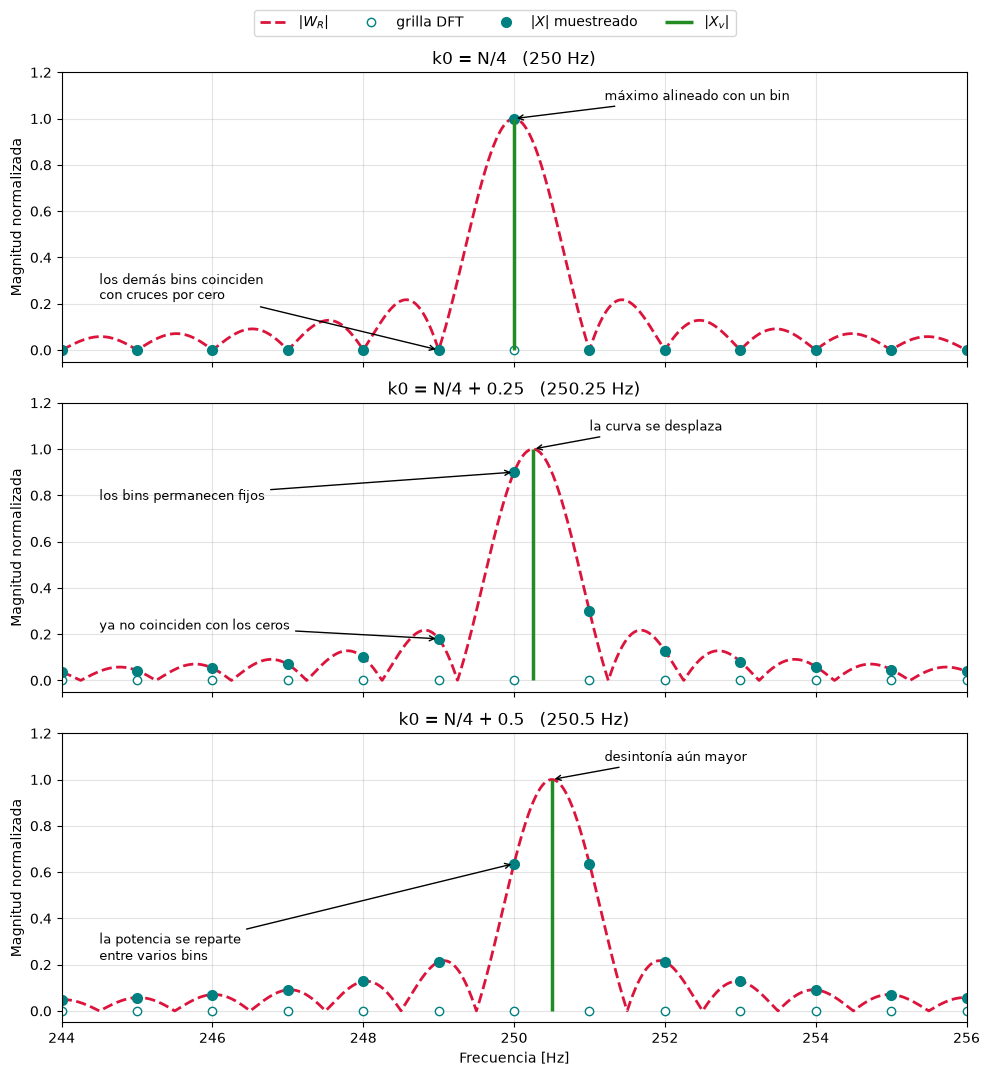

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def dirichlet_mag(f, f0, N):
    """
    Magnitud normalizada del kernel de Dirichlet centrado en f0.
    En este caso, como df = 1 Hz, el eje f también puede leerse como bins.
    """
    x = f - f0

    num = np.sin(np.pi * x)
    den = np.sin(np.pi * x / N)

    y = np.zeros_like(x, dtype=float)

    idx = np.abs(den) > 1e-12
    y[idx] = np.abs(num[idx] / den[idx]) / N
    y[~idx] = 1.0

    return y


# -------------------------------------------------------
# Parámetros
# -------------------------------------------------------
N = 1000

# Eje continuo para dibujar la curva
f_cont = np.linspace(244, 256, 4000)

# Grilla fija de la DFT (bins)
f_bins = np.arange(244, 257, 1)

# Tres casos del TP
f0_vals = [250.0, 250.25, 250.5]
titulos = ['k0 = N/4   (250 Hz)',
           'k0 = N/4 + 0.25   (250.25 Hz)',
           'k0 = N/4 + 0.5   (250.5 Hz)']


# -------------------------------------------------------
# Figura
# -------------------------------------------------------
fig, ax = plt.subplots(3, 1, figsize=(10, 11), sharex=True, sharey=True)

for i in range(3):

    f0 = f0_vals[i]

    # Curva continua del kernel de Dirichlet desplazado
    y_cont = dirichlet_mag(f_cont, f0, N)

    # Valores muestreados en la grilla de la DFT
    y_bins = dirichlet_mag(f_bins, f0, N)

    # |W_R| desplazada
    ax[i].plot(
        f_cont, y_cont,
        '--',
        color='crimson',
        linewidth=2,
        label=r'$|W_R|$'
    )

    # bins de la DFT dibujados sobre el eje
    ax[i].plot(
        f_bins, np.zeros_like(f_bins),
        'o',
        markersize=6,
        markerfacecolor='white',
        markeredgecolor='teal',
        label='grilla DFT'
    )

    # muestras que toma la DFT
    ax[i].plot(
        f_bins, y_bins,
        'o',
        color='teal',
        markersize=7,
        label=r'$|X|$ muestreado'
    )

    # |X_v| ideal: línea vertical en la frecuencia de la senoidal
    ax[i].vlines(
        f0, 0, 1,
        colors='forestgreen',
        linewidth=2.5,
        label=r'$|X_v|$'
    )

    ax[i].set_title(titulos[i])
    ax[i].set_ylabel('Magnitud normalizada')
    ax[i].set_xlim(244, 256)
    ax[i].set_ylim(-0.05, 1.2)
    ax[i].grid(True, alpha=0.35)

    # Anotaciones
    if i == 0:
        ax[i].annotate(
            'máximo alineado con un bin',
            xy=(f0, 1.0),
            xytext=(251.2, 1.08),
            arrowprops=dict(arrowstyle='->'),
            fontsize=9
        )
        ax[i].annotate(
            'los demás bins coinciden\ncon cruces por cero',
            xy=(249, 0),
            xytext=(244.5, 0.22),
            arrowprops=dict(arrowstyle='->'),
            fontsize=9
        )

    elif i == 1:
        ax[i].annotate(
            'la curva se desplaza',
            xy=(f0, 1.0),
            xytext=(251.0, 1.08),
            arrowprops=dict(arrowstyle='->'),
            fontsize=9
        )
        ax[i].annotate(
            'los bins permanecen fijos',
            xy=(250, y_bins[np.where(f_bins == 250)][0]),
            xytext=(244.5, 0.78),
            arrowprops=dict(arrowstyle='->'),
            fontsize=9
        )
        ax[i].annotate(
            'ya no coinciden con los ceros',
            xy=(249, y_bins[np.where(f_bins == 249)][0]),
            xytext=(244.5, 0.22),
            arrowprops=dict(arrowstyle='->'),
            fontsize=9
        )

    else:
        ax[i].annotate(
            'desintonía aún mayor',
            xy=(f0, 1.0),
            xytext=(251.2, 1.08),
            arrowprops=dict(arrowstyle='->'),
            fontsize=9
        )
        ax[i].annotate(
            'la potencia se reparte\nentre varios bins',
            xy=(250, y_bins[np.where(f_bins == 250)][0]),
            xytext=(244.5, 0.22),
            arrowprops=dict(arrowstyle='->'),
            fontsize=9
        )

ax[2].set_xlabel('Frecuencia [Hz]')

# Leyenda general
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.98))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

En las figuras conceptuales se mantienen fijos los bins en los que la DFT toma muestras, mientras que se desplaza la frecuencia de la senoidal y, como consecuencia, también el kernel de Dirichlet asociado.

En el primer caso, correspondiente a $k_0=N/4$, el máximo del lóbulo principal coincide exactamente con uno de los bins de la DFT. Al mismo tiempo, los restantes bins coinciden con los cruces por cero del kernel de Dirichlet. Por esta razón, se espera obtener potencia únicamente en el bin correspondiente a la frecuencia de la señal y valores nulos en los demás.

En el segundo y tercer caso, al aumentar $k_0$ en $0.25$ y $0.5$, el kernel se desplaza respecto de la grilla de la DFT. Los bins permanecen en las mismas posiciones, pero dejan de coincidir con sus cruces por cero. Por lo tanto, al muestrear el espectro aparecen valores distintos de cero en varios bins.

Este es el mecanismo que se espera observar como desparramo espectral: la potencia que en el caso sintonizado aparece concentrada en un único bin pasa a distribuirse entre varios bins cuando la frecuencia deja de ser un múltiplo entero de $\Delta f$.

### Resultados de la simulación

A continuación se muestran los espectros obtenidos para los tres valores de $k_0$. Se representan inicialmente por separado utilizando los mismos límites en ambos ejes, con el objetivo de comparar cómo cambia la distribución de potencia al aumentar la desintonía.

In [6]:
# Frecuencias de las tres senoidales
ff1 = (N/4) * df
ff2 = ((N/4) + 0.25) * df
ff3 = ((N/4) + 0.5) * df

# Generación de las señales
tt, xx1 = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff1, ph=ph, nn=N, fs=fs)
tt, xx2 = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff2, ph=ph, nn=N, fs=fs)
tt, xx3 = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff3, ph=ph, nn=N, fs=fs)

# DFT normalizada
xx1_k = (1/N) * np.fft.fft(xx1)
xx2_k = (1/N) * np.fft.fft(xx2)
xx3_k = (1/N) * np.fft.fft(xx3)

# Potencia espectral unilateral
pot_xx1_k = 2 * np.abs(xx1_k[0:N//2])**2
pot_xx2_k = 2 * np.abs(xx2_k[0:N//2])**2
pot_xx3_k = 2 * np.abs(xx3_k[0:N//2])**2

# Potencia en dB
pot_xx1_k_db = 10 * np.log10(pot_xx1_k)
pot_xx2_k_db = 10 * np.log10(pot_xx2_k)
pot_xx3_k_db = 10 * np.log10(pot_xx3_k)

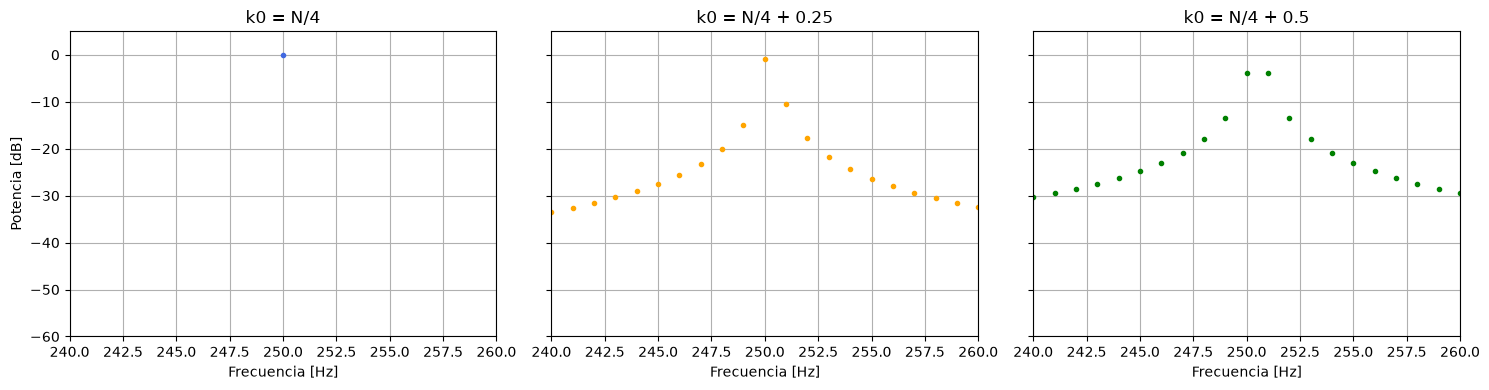

In [7]:
#Visualizo
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

# k0 = N/4
ax[0].plot(
    bins,
    pot_xx1_k_db,
    'o',
    color='royalblue',
    markersize=3
)

ax[0].set_title('k0 = N/4')


# k0 = N/4 + 0.25
ax[1].plot(
    bins,
    pot_xx2_k_db,
    'o',
    color='orange',
    markersize=3
)

ax[1].set_title('k0 = N/4 + 0.25')


# k0 = N/4 + 0.5
ax[2].plot(
    bins,
    pot_xx3_k_db,
    'o',
    color='green',
    markersize=3
)

ax[2].set_title('k0 = N/4 + 0.5')


# Configuración común
for i in range(3):

    ax[i].set_xlim(240, 260)
    ax[i].set_ylim(-60, 5)

    ax[i].set_xlabel('Frecuencia [Hz]')
    ax[i].grid()

ax[0].set_ylabel('Potencia [dB]')

plt.tight_layout()
plt.show()

Los resultados individuales muestran el comportamiento esperado. Para $k_0=N/4$ se observa prácticamente toda la potencia concentrada en un único bin, mientras que para $k_0=N/4+0.25$ y $k_0=N/4+0.5$ aparecen varios bins con potencia apreciable alrededor de la frecuencia de la señal.

Para facilitar la comparación directa entre los tres casos, a continuación se representan los espectros sobre los mismos ejes.

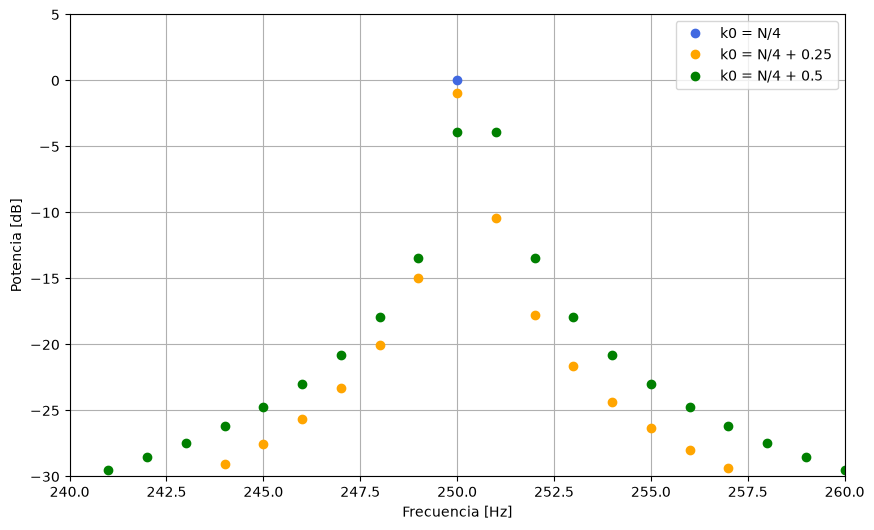

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(bins, pot_xx1_k_db, 'o',
         color='royalblue', label='k0 = N/4')

plt.plot(bins, pot_xx2_k_db, 'o',
         color='orange', label='k0 = N/4 + 0.25')

plt.plot(bins, pot_xx3_k_db, 'o',
         color='green', label='k0 = N/4 + 0.5')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')

plt.xlim(240, 260)
plt.ylim(-30, 5)

plt.grid()
plt.legend()
plt.show()

En la figura comparativa se observa con claridad que el caso $k_0=N/4$ presenta un único bin con potencia significativa. Este resultado coincide con lo esperado teóricamente: al estar la frecuencia de la señal alineada con la grilla de la DFT, el máximo del kernel de Dirichlet coincide con ese bin y los restantes bins coinciden con sus cruces por cero.

En los casos $k_0=N/4+0.25$ y $k_0=N/4+0.5$ el comportamiento cambia. La potencia ya no aparece concentrada en un único punto, sino distribuida entre varios bins vecinos. Esto indica directamente la presencia de desparramo espectral.

El resultado también coincide con la interpretación frecuencial planteada anteriormente. Al modificar la frecuencia de la senoidal se desplaza el kernel de Dirichlet, mientras que la grilla de frecuencias de la DFT permanece fija. Como consecuencia, los bins dejan de coincidir con los cruces por cero y pasan a muestrear valores distintos de cero del lóbulo principal y de los lóbulos laterales.

Por lo tanto, la diferencia entre los tres espectros no implica que se haya perdido potencia, sino que ésta se encuentra distribuida de manera diferente entre los bins de la DFT. En el siguiente inciso se verificará mediante la identidad de Parseval que, a pesar de esta redistribución espectral, la potencia total de la señal se mantiene.

#### Inciso b) Verificación de la potencia mediante Parseval

En este inciso se verificará que los tres casos mantienen una potencia aproximadamente unitaria, independientemente de cómo ésta se distribuya entre los bins de la DFT.

En el dominio temporal, la potencia media se obtiene promediando los valores de $x^2[n]$, por lo que la expresión $P_x=(1/N)\sum x^2[n]$ se implementa directamente como np.mean(x**2).

En el dominio frecuencial, como la DFT fue normalizada previamente por $1/N$, la identidad de Parseval permite calcular la potencia como la suma de los módulos cuadrados de todos los coeficientes, es decir, mediante np.sum(np.abs(X)**2).

Se calculan ambas potencias para comprobar numéricamente que el valor obtenido a partir de las muestras temporales coincide con la potencia total distribuida entre los bins de la DFT.

In [9]:
# Potencia en el dominio temporal
pot_tiempo_xx1 = np.mean(xx1**2)
pot_tiempo_xx2 = np.mean(xx2**2)
pot_tiempo_xx3 = np.mean(xx3**2)


# Potencia en el dominio frecuencial
pot_frec_xx1 = np.sum(np.abs(xx1_k)**2)
pot_frec_xx2 = np.sum(np.abs(xx2_k)**2)
pot_frec_xx3 = np.sum(np.abs(xx3_k)**2)

print("=" * 45)
print('CASO k0 = N/4')
print('Potencia temporal =', pot_tiempo_xx1)
print('Potencia frecuencial =', pot_frec_xx1)

print('\nCASO k0 = N/4 + 0.25')
print('Potencia temporal =', pot_tiempo_xx2)
print('Potencia frecuencial =', pot_frec_xx2)

print('\nCASO k0 = N/4 + 0.5')
print('Potencia temporal =', pot_tiempo_xx3)
print('Potencia frecuencial =', pot_frec_xx3)
print("=" * 45)

CASO k0 = N/4
Potencia temporal = 1.0000000000000002
Potencia frecuencial = 1.0000000000000002

CASO k0 = N/4 + 0.25
Potencia temporal = 0.9989999999999998
Potencia frecuencial = 0.9989999999999997

CASO k0 = N/4 + 0.5
Potencia temporal = 1.0000000000000004
Potencia frecuencial = 1.0000000000000007


Los resultados obtenidos muestran que, para los tres valores de $k_0$, la potencia calculada en el dominio temporal y en el dominio frecuencial coincide y resulta aproximadamente unitaria.

Esto permite verificar numéricamente la identidad de Parseval y, al mismo tiempo, complementar lo observado en el inciso anterior. Aunque los tres espectros presentan formas muy diferentes, la potencia total de las señales no cambia.

Para $k_0=N/4$, prácticamente toda la potencia se encuentra concentrada en un único bin. En cambio, para $k_0=N/4+0.25$ y $k_0=N/4+0.5$, el desparramo espectral hace que esa misma potencia aparezca distribuida entre varios bins. Por este motivo, los máximos individuales de estos espectros son menores, pero la suma de la potencia de todos sus componentes continúa dando aproximadamente uno.

Por lo tanto, Parseval permite comprobar que el desparramo espectral no implica una pérdida de potencia, sino una redistribución de ésta entre los distintos bins de la DFT. Esto explica por qué señales senoidales con frecuencias muy próximas pueden presentar espectros visualmente muy diferentes aun conservando la misma potencia total.

#### Inciso c) Zero padding

Se repetirá el cálculo de los espectros agregando $9N$ ceros al final de las $N$ muestras originales. La FFT tendrá entonces una longitud total de
$N_{FFT}=N+9N=10N$

La nueva separación entre puntos de frecuencia será $\Delta f_{zp}=f_s/N_{FFT}=0.1,Hz$.

En lugar de crear explícitamente un vector de ceros, se utilizará el parámetro n de np.fft.fft. Al solicitar una FFT de $10N$ puntos a partir de una señal de longitud $N$, NumPy completa automáticamente las muestras restantes con ceros.

In [ ]:
# Longitud de la FFT luego del zero padding
N_fft = 10 * N

# Nueva separación entre bins
df_zp = fs / N_fft

# Eje de frecuencias positivo
bins_zp = np.arange(0, N_fft//2) * df_zp

Se calcula nuevamente la FFT para las tres señales utilizando $10N$ puntos. La normalización continúa realizándose respecto de las $N$ muestras originales, ya que los ceros agregados no representan nuevas muestras de información.

Luego se calcula nuevamente la potencia espectral unilateral y se expresa en decibeles.

In [ ]:
# FFT de 10N puntos.
# NumPy completa automáticamente con ceros hasta N_fft.
xx1_zp_k = (1/N) * np.fft.fft(xx1, n=N_fft)
xx2_zp_k = (1/N) * np.fft.fft(xx2, n=N_fft)
xx3_zp_k = (1/N) * np.fft.fft(xx3, n=N_fft)


# Potencia espectral unilateral
pot_xx1_zp = 2 * np.abs(xx1_zp_k[0:N_fft//2])**2
pot_xx2_zp = 2 * np.abs(xx2_zp_k[0:N_fft//2])**2
pot_xx3_zp = 2 * np.abs(xx3_zp_k[0:N_fft//2])**2


# Potencia en dB
pot_xx1_zp_db = 10 * np.log10(pot_xx1_zp)
pot_xx2_zp_db = 10 * np.log10(pot_xx2_zp)
pot_xx3_zp_db = 10 * np.log10(pot_xx3_zp)

Al disponer ahora de puntos separados cada $0.1\,Hz$, se puede observar con mayor detalle la forma del espectro producido por la ventana rectangular.

Para analizar el efecto del *zero padding* se representan los espectros utilizando distintos niveles de acercamiento. Primero se muestra el espectro completo hasta la frecuencia de Nyquist. Luego se realizan acercamientos sucesivos alrededor de $250\,Hz$ para observar con mayor detalle el muestreo del espectro, la forma de los lóbulos y sus cruces por cero.

In [ ]:
# Piso numérico únicamente para visualizar el espectro completo
pot_xx1_zp_db_plot = 10 * np.log10(pot_xx1_zp + 1e-12)
pot_xx2_zp_db_plot = 10 * np.log10(pot_xx2_zp + 1e-12)
pot_xx3_zp_db_plot = 10 * np.log10(pot_xx3_zp + 1e-12)

fig, ax = plt.subplots(2, 2, figsize=(14, 10))


# ------------------------------------------------------
# 1) Espectro completo
# ------------------------------------------------------
ax[0,0].plot(bins_zp, pot_xx1_zp_db_plot, 'o',
             markersize=2, label='k0 = N/4')

ax[0,0].plot(bins_zp, pot_xx2_zp_db_plot, 'o',
             markersize=2, label='k0 = N/4 + 0.25')

ax[0,0].plot(bins_zp, pot_xx3_zp_db_plot, 'o',
             markersize=2, label='k0 = N/4 + 0.5')

ax[0,0].set_title('Espectro completo')
ax[0,0].set_xlim(0, 500)
ax[0,0].set_ylim(-125, 5)

ax[0,0].set_xlabel('Frecuencia [Hz]')
ax[0,0].set_ylabel('Potencia [dB]')

ax[0,0].grid()
ax[0,0].legend()


# ------------------------------------------------------
# 2) Zoom fuerte - puntos discretos
# ------------------------------------------------------
ax[0,1].plot(bins_zp, pot_xx1_zp_db, 'o',
             markersize=3, label='k0 = N/4')

ax[0,1].plot(bins_zp, pot_xx2_zp_db, 'o',
             markersize=3, label='k0 = N/4 + 0.25')

ax[0,1].plot(bins_zp, pot_xx3_zp_db, 'o',
             markersize=3, label='k0 = N/4 + 0.5')

# líneas de referencia de los k0
ax[0,1].axvline(250.0, color='C0', linestyle='--', linewidth=1)
ax[0,1].axvline(250.25, color='C1', linestyle='--', linewidth=1)
ax[0,1].axvline(250.5, color='C2', linestyle='--', linewidth=1)

# línea horizontal de referencia en 0 dB
ax[0,1].axhline(0, color='gray', linestyle='--', linewidth=1)

ax[0,1].set_title('Zoom sobre el lóbulo principal')
ax[0,1].set_xlim(249, 252)
ax[0,1].set_ylim(-20, 5)

ax[0,1].set_xticks(np.arange(249, 253, 1))
ax[0,1].set_xlabel('Frecuencia [Hz]')
ax[0,1].set_ylabel('Potencia [dB]')

ax[0,1].grid()
ax[0,1].legend()


# ------------------------------------------------------
# 3) Zoom intermedio - lóbulos
# ------------------------------------------------------
ax[1,0].plot(bins_zp, pot_xx1_zp_db, '-o',
             markersize=2, label='k0 = N/4')

ax[1,0].plot(bins_zp, pot_xx2_zp_db, '-o',
             markersize=2, label='k0 = N/4 + 0.25')

ax[1,0].plot(bins_zp, pot_xx3_zp_db, '-o',
             markersize=2, label='k0 = N/4 + 0.5')

ax[1,0].set_title('Lóbulo principal y lóbulos laterales')
ax[1,0].set_xlim(245, 255)
ax[1,0].set_ylim(-60, 5)

ax[1,0].set_xlabel('Frecuencia [Hz]')
ax[1,0].set_ylabel('Potencia [dB]')

ax[1,0].grid()
ax[1,0].legend()


# ------------------------------------------------------
# 4) Cruces por cero
# ------------------------------------------------------
ax[1,1].plot(bins_zp, pot_xx1_zp_db, '-o',
             markersize=2, label='k0 = N/4')

ax[1,1].plot(bins_zp, pot_xx2_zp_db, '-o',
             markersize=2, label='k0 = N/4 + 0.25')

ax[1,1].plot(bins_zp, pot_xx3_zp_db, '-o',
             markersize=2, label='k0 = N/4 + 0.5')

ax[1,1].set_title('Cruces por cero')
ax[1,1].set_xlim(240, 260)
ax[1,1].set_ylim(-300, 5)

ax[1,1].set_xticks(np.arange(240, 261, 1))
ax[1,1].set_xlabel('Frecuencia [Hz]')
ax[1,1].set_ylabel('Potencia [dB]')

ax[1,1].grid()
ax[1,1].legend()

plt.tight_layout()
plt.show()

### Análisis del inciso c)

El zero padding complementa el análisis del inciso a), ya que no modifica el contenido espectral de la señal sino que permite visualizar con más detalle el mismo fenómeno de desparramo espectral. Al agregar $9N$ ceros, la FFT pasa a calcularse con $10N$ puntos y la grilla frecuencial se hace diez veces más fina, pasando de $\Delta f=1\,Hz$ a $\Delta f_{zp}=0.1\,Hz$. Por eso, lo que se observa es un espectro interpolado: no aparecen nuevas componentes, sino más puntos de muestreo sobre la misma envolvente espectral.

En el espectro completo de la subfigura superior izquierda se observa con claridad la envolvente asociada a la ventana rectangular, que ahora aparece mucho mejor definida que en el inciso a). La línea horizontal cercana a $-120\,dB$ no corresponde a una componente real de la señal, sino al piso numérico introducido al graficar $10\log_{10}(P+10^{-12})$ para evitar el logaritmo de cero. Como la curva verde se dibuja en último lugar, es la que queda visible sobre ese piso.
ubfigura superior derecha
El zoom sobre el lóbulo principal en la subfigura superior derecha muestra que el máximo de la curva azul aparece en $250\,Hz$, mientras que el de la verde aparece en $250.5\,Hz$, en acuerdo con sus respectivos valores de $k_0$. En el caso naranja, el lóbulo principal está centrado en $250.25\,Hz$, pero esa frecuencia no pertenece exactamente a la nueva grilla de $0.1\,Hz$, de modo que el máximo queda representado por puntos a ambos lados. Esta subfigura muestra una de las utilidades principales del zero padding: permite ubicar con mayor precisión la posición de los máximos y describir mejor la forma local del espectro.

En la subfigura inferior izquierda se observa claramente el lóbulo principal junto con los lóbulos laterales, es decir, la forma que en el inciso a) solo podía inferirse a partir de unos pocos bins. Para la ventana rectangular utilizada, los primeros cruces por cero se encuentran a $1\,Hz$ a cada lado de la frecuencia central, por lo que el ancho del lóbulo principal es $2\,Hz$, equivalente a $2\Delta f$ de la grilla original. Luego de aplicar zero padding este ancho no cambia; lo que cambia es la separación entre los puntos con los que se representa el espectro, que pasa de $1\,Hz$ a $0.1\,Hz$. Por lo tanto, el mismo lóbulo queda ahora descrito por una cantidad mucho mayor de muestras, haciendo visible con más detalle la estructura espectral asociada a la ventana.

Por ultimo, en la subfigura inferior derecha se distinguen los cruces por cero. Las curvas azul y verde alcanzan valores muy bajos, cercanos a $-300\,dB$, porque algunos puntos de la nueva grilla coinciden prácticamente con los ceros de sus respectivos kernels. En cambio, la curva naranja no desciende tanto, ya que sus cruces por cero no coinciden con los puntos de la grilla de $0.1\,Hz$. Por lo tanto, la diferencia no implica que el caso naranja no tenga ceros, sino que éstos no son muestreados exactamente por la FFT.

En conjunto, las figuras muestran que el zero padding sirve principalmente para visualizar mejor lo que ya se había concluido en el inciso a): cuando la frecuencia coincide con un bin, la potencia queda concentrada; cuando la señal está desintonizada, la potencia se reparte entre varios bins. La diferencia es que ahora esa redistribución puede observarse con mucha mayor claridad en la forma del lóbulo principal, en los lóbulos laterales y en los cruces por cero.

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Conclusiones</h2>
</div>


A partir de este trabajo se comprendió con mayor claridad que, al trabajar con una cantidad finita de muestras, siempre existe una ventana implícita. Hasta ahora se utilizaban bloques de $N$ muestras sin relacionarlo directamente con el concepto de ventaneo, pero en este análisis quedó claro que seleccionar un tramo finito de una señal equivale a multiplicarla por una ventana rectangular, y que esto tiene consecuencias directas sobre su representación espectral.

También se analizó el fenómeno de desparramo espectral. Se observó que cuando la frecuencia de una senoidal coincide con la grilla de la DFT, la potencia queda concentrada en un único bin. En cambio, cuando la frecuencia no coincide con un múltiplo entero de $\Delta f$, los bins dejan de coincidir con los cruces por cero del kernel de Dirichlet y la potencia se distribuye entre varios puntos del espectro. A pesar de esta diferencia en la forma espectral, mediante Parseval se verificó que la potencia total se conserva.

El uso de zero padding permitió complementar este análisis, ya que al generar una grilla frecuencial más fina se pudo visualizar con mayor detalle la forma del espectro, los lóbulos laterales y los cruces por cero. Se comprobó así que agregar ceros no introduce nueva información ni modifica el fenómeno de desparramo, sino que permite observar mejor un espectro que ya estaba determinado por las muestras originales.

Personalmente, este trabajo también me ayudó a ordenar conceptos que hasta ahora me resultaban un poco abstractos, en particular la relación entre DTFT, DFT y FFT. Quedó más claro qué representa cada transformada, cómo la DFT toma muestras del espectro continuo en frecuencia y cómo interviene la grilla definida por $\Delta f$. Además, permitió comprender mejor el significado de las densidades espectrales de potencia y la relación entre multiplicación en tiempo, ventaneo y convolución en frecuencia.